In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

from mylib.fig_tools import adjust_general

%matplotlib widget

In [14]:
twoth_bef, int_bef = np.loadtxt('data/1802021_before.xy', delimiter='\t', comments="#", skiprows=1,usecols=(0,1), unpack=True)
twoth_aft, int_aft = np.loadtxt('data/1802021_after.xy', delimiter='\t', comments="#", skiprows=1,usecols=(0,1), unpack=True)

print(twoth_bef.size)

3770


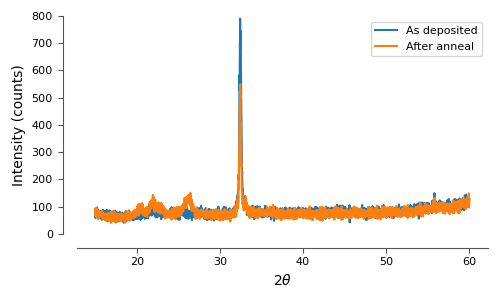

In [15]:
plt.figure(figsize=(5, 3))
plt.plot(twoth_bef, int_bef, label='As deposited')
plt.plot(twoth_aft, int_aft, label='After anneal')

plt.xlabel(r"2$\theta$")
plt.ylabel("Intensity (counts)")
plt.ylim([0, 800])
adjust_general(plt.gca())
plt.legend()
plt.tight_layout()
plt.savefig('figures/raw_xrd.png', dpi=300)

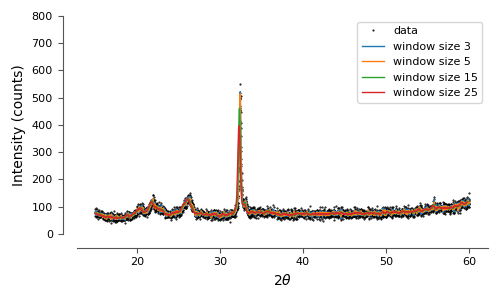

In [16]:
x = twoth_aft
y = int_aft

# ChatGPT
import numpy as np

def moving_average(y, window_size=5):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')


plt.figure(figsize=(5,3))
plt.plot(x, y, 'k.', ms=1, label='data')

for wdw in [3,5,15,25]:
    y_smooth = moving_average(y, window_size=wdw)
    x_smooth = x[:len(y_smooth)]  # adjust x accordingly
    plt.plot(x_smooth, y_smooth, lw=1, label='window size ' + str(wdw))

plt.xlabel(r"2$\theta$")
plt.ylabel("Intensity (counts)")
plt.ylim([0, 800])
adjust_general(plt.gca())
plt.legend()
plt.tight_layout()
plt.savefig('figures/convolution_xrd.png', dpi=300)



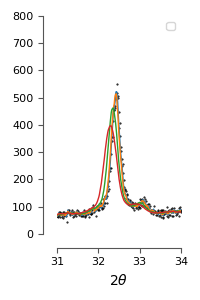

In [17]:
plt.figure(figsize=(5,3))
plt.plot(x, y, 'k.', ms=1, label='data')

for wdw in [3,5,15,25]:
    y_smooth = moving_average(y, window_size=wdw)
    x_smooth = x[:len(y_smooth)]  # adjust x accordingly
    plt.plot(x_smooth, y_smooth, lw=1, label='window size ' + str(wdw))

plt.xlabel(r"2$\theta$")
plt.ylabel("Intensity (counts)")
plt.ylim([0, 800])
adjust_general(plt.gca())
plt.legend()
plt.tight_layout()

plt.gcf().set_size_inches(2,3)
plt.legend([])
plt.xlim([31, 34])
plt.ylabel('')
plt.tight_layout()
plt.savefig('figures/convolution_xrd_zoom.png', dpi=300)

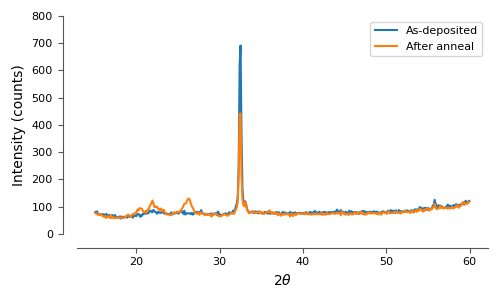

In [18]:
# binning is also an option...
b = binned_statistic(twoth_bef, int_bef, bins=400)
a = binned_statistic(twoth_aft, int_aft, bins=400)

# comments of filip: binning, intensiteit klopt niet voor dunne films. Ga eerder voor pijltjes.

plt.figure(figsize=(5,3))

bin_centers = (b.bin_edges[:-1]  + b.bin_edges[1:]) / 2  

plt.plot(bin_centers, b.statistic, label='As-deposited')
plt.plot(bin_centers, a.statistic, label='After anneal')

plt.xlabel(r"2$\theta$")
plt.ylabel("Intensity (counts)")
plt.ylim([0, 800])
adjust_general(plt.gca())
plt.legend()
plt.tight_layout()
plt.savefig('figures/binned_xrd.png', dpi=300)


Optimal lambda found: 3.16e-05


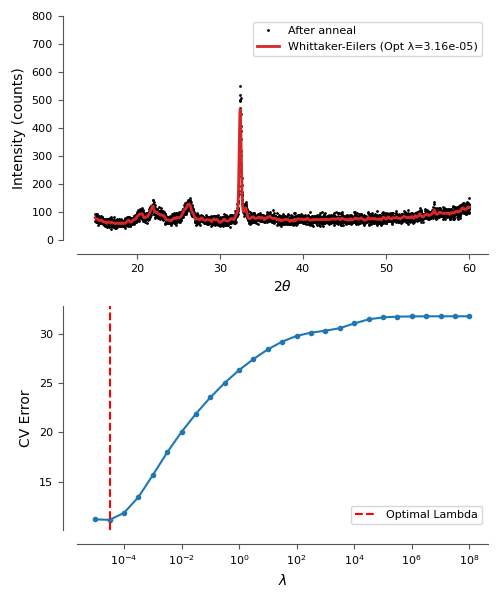

In [19]:
from whittaker_eilers import WhittakerSmoother

x_input = twoth_aft.tolist()
data_to_smooth = int_aft.tolist()

whittaker_smoother = WhittakerSmoother(
    lmbda=100, order=2, data_length=len(data_to_smooth), x_input=x_input
)

optimal_smooth = whittaker_smoother.smooth_optimal(data_to_smooth)
smoothed_signal_pkg = optimal_smooth.get_optimal().get_smoothed()
optimal_lambda = optimal_smooth.get_optimal().get_lambda()
print(f"Optimal lambda found: {optimal_lambda:.2e}")

fig, axes = plt.subplots(2, 1, figsize=(5, 6))

# Plot the noisy signal
axes[0].plot(twoth_aft, int_aft, '.', color='k', label='After anneal', markersize=2)

# Plot the smoothed signal
axes[0].plot(twoth_aft, smoothed_signal_pkg, color='C3', linewidth=2, label=f'Whittaker-Eilers (Opt λ={optimal_lambda:.2e})')
axes[0].set_xlabel(r"2$\theta$")
axes[0].set_ylabel("Intensity (counts)")
axes[0].set_ylim([0, 800])
adjust_general(axes[0])
axes[0].legend(loc='upper right', fontsize=8)

# CVE plot
all_results = optimal_smooth.get_all()
tested_lambdas = [res.get_lambda() for res in all_results]
cv_errors = [res.get_cross_validation_error() for res in all_results]

axes[1].plot(tested_lambdas, cv_errors, 'o-', color='C0')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$\lambda$')
axes[1].set_ylabel('CV Error')
axes[1].axvline(optimal_lambda, color='r', linestyle='--', label='Optimal Lambda')
adjust_general(axes[1])
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/whittaker_xrd.png', dpi=300)
plt.show()